In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
data_dir = Path("data/ExtraSensory.per_uuid_features_labels")
path = next(data_dir.glob("*.csv.gz"))

df = pd.read_csv(path)
participant_id = path.name.split(".")[0]

print("Participant:", participant_id)
print("Shape:", df.shape)

df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)

feature_cols = [
    column
    for column in df.columns
    if column != "timestamp"
    and not column.startswith("label:")
    and column != "label_source"
]

label_cols = [
    column for column in df.columns
    if column.startswith("label:")
]


Participant: A7599A50-24AE-46A6-8EA6-2576F1011D81
Shape: (3898, 278)


/var/folders/hy/hxwg16y1155cv84zdhsj9grc0000gn/T/ipykernel_22557/2604105682.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)


Features: 226
Labels: 51
                   datetime  label:LYING_DOWN  label:SITTING  \
0 2015-11-05 22:24:57+00:00               0.0            1.0   
1 2015-11-05 22:25:57+00:00               0.0            1.0   
2 2015-11-05 22:26:57+00:00               0.0            1.0   
3 2015-11-05 22:28:07+00:00               0.0            1.0   
4 2015-11-05 22:29:08+00:00               0.0            1.0   

   label:FIX_walking  label:FIX_running  label:BICYCLING  
0                0.0                NaN              NaN  
1                0.0                NaN              NaN  
2                0.0                NaN              NaN  
3                0.0                NaN              NaN  
4                0.0                NaN              NaN  


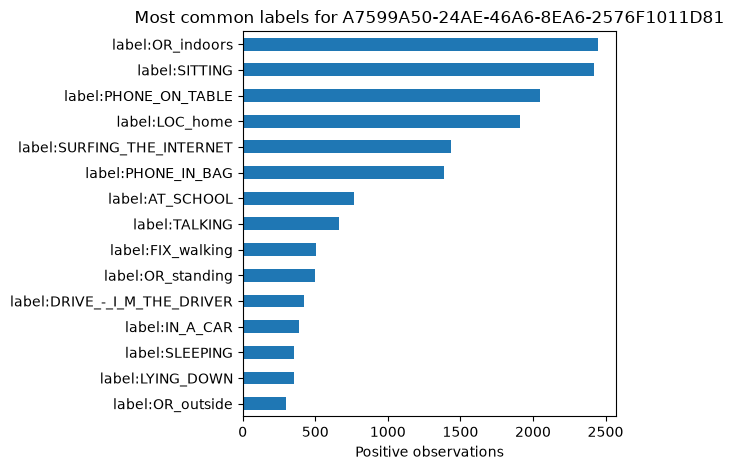

In [13]:
print("Features:", len(feature_cols))
print("Labels:", len(label_cols))
print(df[["datetime", *label_cols[:5]]].head())

label_counts = df[label_cols].eq(1).sum().sort_values(ascending=False)

label_counts.head(15).sort_values().plot.barh()
plt.title(f"Most common labels for {participant_id}")
plt.xlabel("Positive observations")
plt.tight_layout()
plt.show()